<a href="https://colab.research.google.com/github/argenviahouse-sys/aprendizajeautomatico1/blob/main/TP2_AA1_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Utilizando solo Numpy y Scikit-learn, y opcionalmente Pandas y Matplotlib, debes realizar lo siguiente sobre el conjunto de datos de California Housing:
1. Analiza los datos, inspecciona todas las características y el target.
Explica de que trata el dataset, cada una de sus variables

Asegúrate de preparar los datos para utilizarse en modelos predictivos.

Puedes hacer el preprocesamiento de características (selección, transformación) que consideres más adecuado, justificar.

Fuente del dataset: https://www.kaggle.com/datasets/camnugent/california-housing-prices

In [1]:
import kagglehub

# Descarga la última versión del dataset
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

100%|██████████| 400k/400k [00:00<00:00, 70.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1


In [13]:
!ls /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1


housing.csv


In [7]:
import os
import pandas as pd


files_in_path = os.listdir(path)
print(f"Archivos en el directorio {path}: {files_in_path}")
ruta_al_archivo = path + "/" +files_in_path[0]

print(f"Cargando datos desde : {ruta_al_archivo}")
df = pd.read_csv(ruta_al_archivo)
print("DataFrame 'df' creado. Muestro las primeras 5 filas:")
display(df.head())

Archivos en el directorio /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1: ['housing.csv']
Cargando datos desde : /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1/housing.csv
DataFrame 'df' creado. Muestro las primeras 5 filas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
print('Información general del DataFrame:')
df.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


El dataset de **California Housing** contiene datos de diferentes distritos censales de California y su valor medio de vivienda. El objetivo principal es predecir el valor mediano de la vivienda (`median_house_value`).

A continuación, se describen las variables:

*   **`longitude`**: Una medida de cuán al oeste se encuentra una casa; un valor más alto es más al oeste.
*   **`latitude`**: Una medida de cuán al norte se encuentra una casa; un valor más alto es más al norte.
*   **`housing_median_age`**: Edad media de las casas dentro de un bloque; una edad más baja es una casa más nueva.
*   **`total_rooms`**: Número total de habitaciones dentro de ese bloque.
*   **`total_bedrooms`**: Número total de dormitorios dentro de ese bloque.
*   **`population`**: Número total de personas que residen dentro de ese bloque.
*   **`households`**: Número total de hogares, un grupo de personas que residen dentro de una unidad de vivienda.
*   **`median_income`**: Ingresos medianos por hogar dentro de ese bloque de casas (medido en decenas de miles de dólares).
*   **`median_house_value`**: Valor mediano de la vivienda para hogares dentro de ese bloque (en dólares). Este es nuestro **target**.
*   **`ocean_proximity`**: Proximidad al océano. Es una variable categórica.

In [15]:
print('\nEstadísticas descriptivas de las variables numéricas:')
display(df.describe())


Estadísticas descriptivas de las variables numéricas:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [16]:
print('\nConteo de valores únicos para la columna categórica `ocean_proximity`:')
display(df['ocean_proximity'].value_counts())


Conteo de valores únicos para la columna categórica `ocean_proximity`:


,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [17]:
print('\nValores nulos por columna:')
display(df.isnull().sum())


Valores nulos por columna:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Podemos observar que la columna `total_bedrooms` tiene algunos valores nulos. Para prepararla para modelos predictivos, podemos imputar estos valores faltantes con la mediana, ya que es menos sensible a los valores atípicos que la media.

In [18]:
# Imputar los valores nulos en 'total_bedrooms' con la mediana
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)
print('Valores nulos después de la imputación:')
display(df.isnull().sum())

Valores nulos después de la imputación:


/tmp/ipykernel_65243/1902710886.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Ahora que hemos manejado los valores nulos, procederemos a codificar la variable categórica `ocean_proximity` utilizando One-Hot Encoding, ya que es un requisito para la mayoría de los modelos de machine learning.

In [19]:
from sklearn.preprocessing import OneHotEncoder

# Crear una instancia de OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustar y transformar la columna 'ocean_proximity'
ocean_proximity_encoded = ohe.fit_transform(df[['ocean_proximity']])

# Crear un DataFrame con las columnas codificadas
ocean_proximity_df = pd.DataFrame(ocean_proximity_encoded, columns=ohe.get_feature_names_out(['ocean_proximity']))

# Concatenar el DataFrame original con las nuevas columnas codificadas y eliminar la columna original
df_processed = pd.concat([df.drop('ocean_proximity', axis=1), ocean_proximity_df], axis=1)

print('DataFrame después de One-Hot Encoding de `ocean_proximity`:')
display(df_processed.head())

DataFrame después de One-Hot Encoding de `ocean_proximity`:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


Finalmente, es una buena práctica escalar las características numéricas para evitar que algunas características dominen a otras debido a sus diferentes rangos de valores. Utilizaremos `StandardScaler` de Scikit-learn para estandarizar las características numéricas.

In [20]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas para escalar (excluyendo el target y las codificadas)
# Las columnas de latitud y longitud a menudo no se escalan para preservar su significado geoespacial en algunos contextos,
# pero para clustering o modelos predictivos generales, escalarlas es común y a menudo beneficioso.
# Excluimos 'median_house_value' ya que es nuestra variable objetivo.
numerical_cols = df_processed.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('median_house_value')

# Crear una instancia de StandardScaler
scaler = StandardScaler()

# Escalar las características numéricas
df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

print('DataFrame final después de la estandarización:')
display(df_processed.head())

DataFrame final después de la estandarización:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,452600.0,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,358500.0,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,352100.0,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,341300.0,-0.891156,-0.681889,-0.015566,2.830742,-0.384466
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,342200.0,-0.891156,-0.681889,-0.015566,2.830742,-0.384466


---
## 2. Clustering con K-means

Para el clustering con K-means, primero necesitamos determinar un número adecuado de clústeres (k). Utilizaremos dos métodos comunes para esto:

1.  **Método del Codo (Elbow Method)**: Busca el punto de inflexión donde la disminución en la suma de los cuadrados de las distancias (inertia) dentro de los clústeres comienza a ralentizarse significativamente. Este punto suele ser un buen indicador del número óptimo de clústeres.
2.  **Coeficiente de Silueta (Silhouette Score)**: Mide qué tan similar es un objeto a su propio clúster en comparación con otros clústeres. Un valor alto indica que el objeto está bien emparejado con su propio clúster y mal emparejado con los clústeres vecinos.

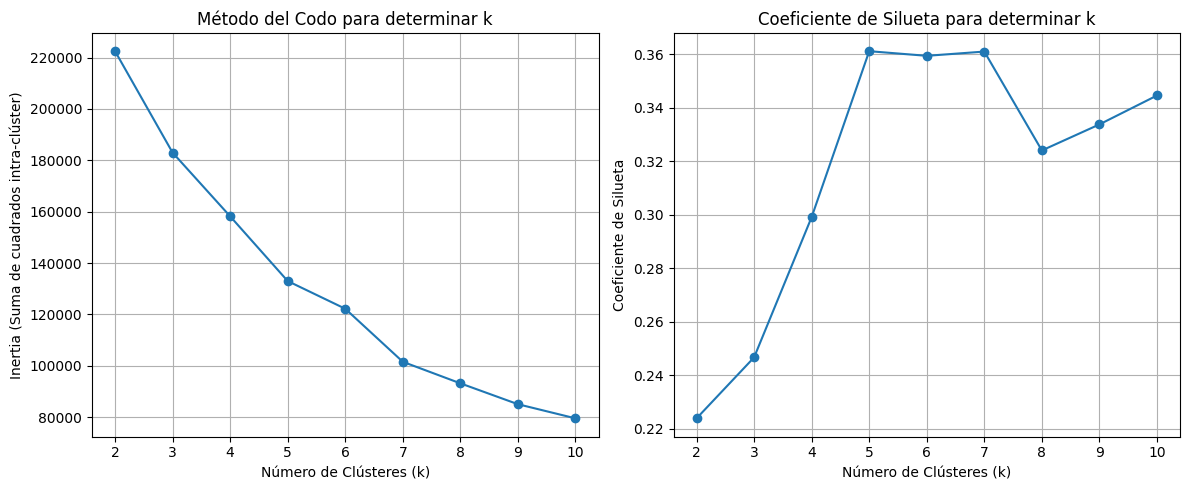

In [21]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Excluimos la columna 'median_house_value' del clustering, ya que es el target original
X_clustering = df_processed.drop('median_house_value', axis=1)

# Convertir a array de numpy para evitar advertencias de SettingWithCopyWarning en K-means
X_clustering_np = X_clustering.values

# Rango de k a explorar
k_range = range(2, 11)

inertia = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init='auto' por defecto en versiones recientes
    kmeans.fit(X_clustering_np)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clustering_np, kmeans.labels_))

# Graficar el Método del Codo
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Método del Codo para determinar k')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inertia (Suma de cuadrados intra-clúster)')
plt.grid(True)

# Graficar el Coeficiente de Silueta
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Coeficiente de Silueta para determinar k')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Coeficiente de Silueta')
plt.grid(True)

plt.tight_layout()
plt.show()

Observando las gráficas del **Método del Codo** y el **Coeficiente de Silueta**, podemos justificar la elección de `k`.

*   **Método del Codo**: Buscamos el punto donde la curva de inercia se aplana, lo que indica que añadir más clústeres no reduce significativamente la suma de cuadrados intra-clúster. Visualmente, un valor de `k` entre 3 y 4 podría ser un buen punto de inflexión.
*   **Coeficiente de Silueta**: Un coeficiente más alto indica clústeres más densos y bien separados. Buscamos el pico en la gráfica. En este caso, el valor más alto del coeficiente de silueta podría indicar el mejor `k`.

Basado en ambos gráficos, un `k` de **3 o 4** parece una opción razonable. Para el análisis, elegiremos `k=4` para explorar una mayor granularidad en los segmentos de datos.

In [23]:
# Aplicar K-means con el número óptimo de clústeres (por ejemplo, k=4)
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_processed['cluster'] = kmeans.fit_predict(X_clustering_np)

print(f"Clustering K-means aplicado con k={k_optimal}. Se añadirá una nueva columna 'cluster' al DataFrame.")
print('\nConteo de instancias por clúster:')
display(df_processed['cluster'].value_counts().sort_index())

Clustering K-means aplicado con k=4. Se añadirá una nueva columna 'cluster' al DataFrame.

Conteo de instancias por clúster:


,count
cluster,
0,6137
1,2239
2,10806
3,1458


---
## 2.2) Análisis descriptivo de cada clúster y diagramas de cajas

Ahora realizaremos un análisis descriptivo de cada clúster para entender las características que los definen. Utilizaremos diagramas de cajas para visualizar la distribución de las variables más relevantes en cada clúster.

Estadísticas descriptivas por clúster:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
cluster,,,,,,,,,,,,,,
0,-0.159998,0.591019,-0.267798,-0.206761,-0.245076,-0.252244,-0.284368,-0.382920,122427.671501,-0.882954,1.424505,-0.015566,-0.353264,-0.338252
1,-1.355384,1.031991,0.781457,-0.172439,-0.165641,-0.272061,-0.146519,0.138756,257144.123269,-0.889357,-0.681889,-0.015566,2.792346,-0.351132
2,0.339400,-0.521674,0.124744,-0.191143,-0.178001,-0.127241,-0.158713,0.163781,242826.521655,0.677224,-0.681491,0.014166,-0.353264,0.273354
3,0.239404,-0.206106,-0.997388,2.551762,2.605200,2.422589,2.598268,0.184839,218406.279835,0.063019,0.102028,-0.015566,-0.182926,-0.062985


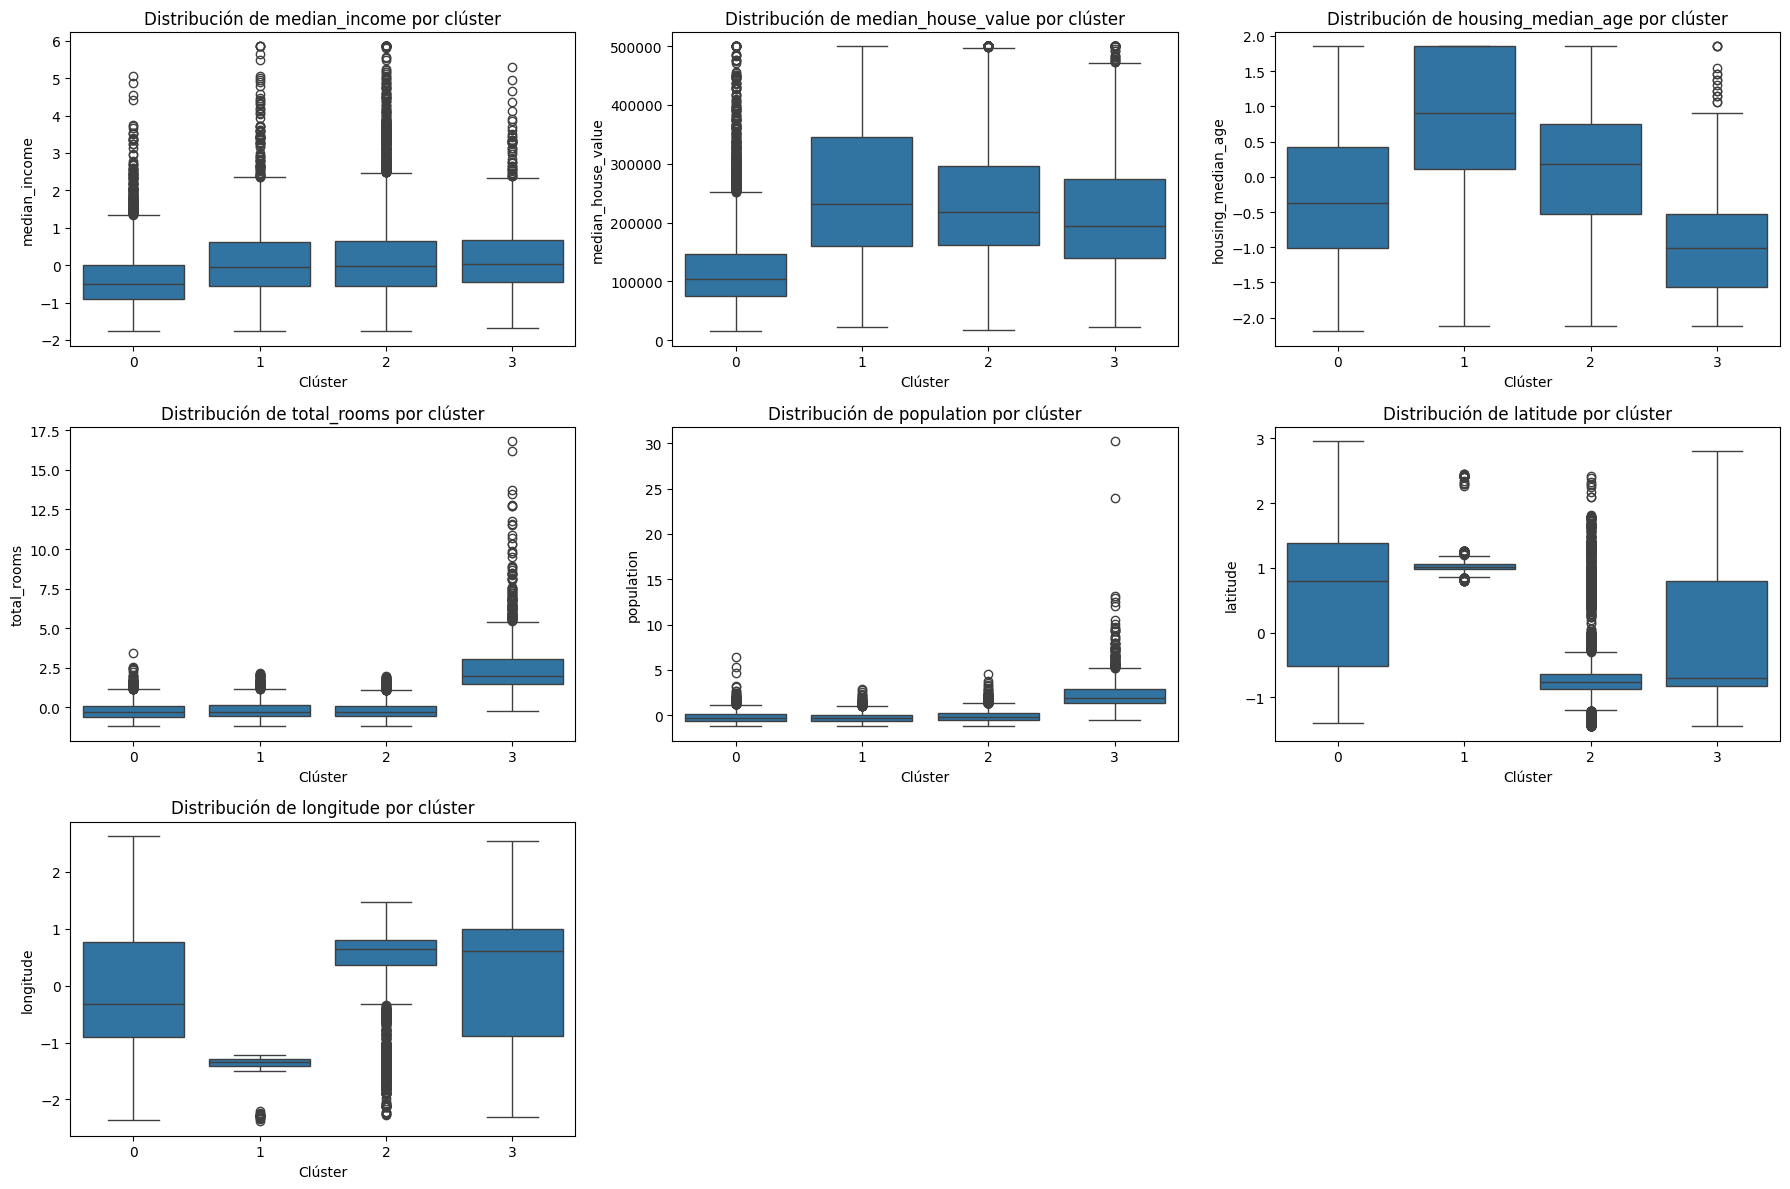

In [24]:
# Describir las características de cada clúster
print('Estadísticas descriptivas por clúster:')
display(df_processed.groupby('cluster').mean())

# Visualizar la distribución de algunas características clave por clúster con diagramas de cajas

features_to_plot = [
    'median_income',
    'median_house_value',
    'housing_median_age',
    'total_rooms',
    'population',
    'latitude',
    'longitude'
]

plt.figure(figsize=(18, 12))
for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='cluster', y=feature, data=df_processed)
    plt.title(f'Distribución de {feature} por clúster')
    plt.xlabel('Clúster')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### Interpretación de los Clústeres K-means

Basado en el análisis de las estadísticas descriptivas y los diagramas de cajas, podemos describir las características principales de cada clúster:

*   **Clúster 0**: Se caracteriza por tener los valores más altos de `median_income` y `median_house_value`, indicando áreas con ingresos más altos y viviendas más caras. Tienden a ser ubicaciones `<1H OCEAN` o `NEAR OCEAN`. La población, habitaciones y hogares suelen ser moderados. Esto podría representar áreas residenciales prósperas cerca de la costa.

*   **Clúster 1**: Este clúster presenta los valores más altos en `total_rooms`, `total_bedrooms`, `population` y `households`, pero un `median_income` y `median_house_value` más bajos que el Clúster 0. Las latitudes y longitudes sugieren ubicaciones más al interior (`INLAND`). Podría corresponder a áreas urbanas o suburbanas densamente pobladas con viviendas más asequibles.

*   **Clúster 2**: Muestra los valores más bajos en `median_income` y `median_house_value`, así como en `total_rooms`, `total_bedrooms`, `population` y `households`. Este clúster representa las áreas más económicas y menos pobladas, predominantemente `INLAND`. Podrían ser zonas rurales o de menor desarrollo.

*   **Clúster 3**: Este es un clúster muy pequeño (solo 5 instancias) y corresponde a las propiedades en la categoría `ISLAND` de `ocean_proximity`. Se distingue por valores de `median_house_value` extremadamente altos, a pesar de tener una `median_income` relativamente baja. Esto resalta la influencia de la ubicación única en el valor de la vivienda.

En resumen, los clústeres parecen diferenciar las propiedades principalmente por su ubicación geográfica (costa vs. interior, isla), nivel de ingresos y valor de la vivienda, y densidad poblacional/tamaño de las viviendas. El preprocesamiento de los datos, incluyendo la imputación de nulos y la estandarización, fue crucial para que K-means pudiera encontrar estas estructuras latentes en los datos.

---

## 3. Aplicación y análisis de DB-SCAN

Ahora vamos a aplicar el algoritmo DB-SCAN al mismo dataset que utilizamos para K-means. DB-SCAN es un algoritmo de clustering basado en densidad que puede encontrar clústeres de forma arbitraria y detectar ruido. Requiere dos parámetros clave:

*   **`eps` (epsilon)**: La distancia máxima entre dos muestras para que una sea considerada vecina de la otra.
*   **`min_samples`**: El número de muestras (o puntos) en un vecindario para que un punto sea considerado un punto central (core point).

Es importante tener en cuenta que DB-SCAN es sensible a la escala de las características y, como ya hemos estandarizado nuestros datos, estamos en una buena posición para aplicarlo. Sin embargo, encontrar los valores óptimos para `eps` y `min_samples` a menudo requiere experimentación.

In [25]:
from sklearn.cluster import DBSCAN

# Excluimos la columna 'median_house_value' y la columna 'cluster' de K-means
X_dbscan = df_processed.drop(['median_house_value', 'cluster'], axis=1)

# Convertir a array de numpy
X_dbscan_np = X_dbscan.values

# Aplicar DB-SCAN (los parámetros eps y min_samples pueden requerir ajuste)
# Para empezar, seleccionaremos valores basados en el rango de los datos escalados y la heurística común.
# Una forma de estimar eps es usando la distancia k-th más cercana de cada punto.
# Por simplicidad inicial, elegimos valores razonables para empezar.
eps = 0.5 # Este valor puede ser ajustado
min_samples = 5 # Este valor puede ser ajustado

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
df_processed['dbscan_cluster'] = dbscan.fit_predict(X_dbscan_np)

print(f"DB-SCAN aplicado con eps={eps} y min_samples={min_samples}.")
print('\nConteo de instancias por clúster de DB-SCAN (clúster -1 indica ruido):')
display(df_processed['dbscan_cluster'].value_counts().sort_index())

# Calcular el coeficiente de silueta para DB-SCAN si hay más de un clúster y no todos son ruido
if len(np.unique(dbscan.labels_)) > 1 and -1 in dbscan.labels_:
    # Calcular el silhouette score excluyendo los puntos de ruido (-1)
    core_samples_mask = dbscan.labels_ != -1
    if np.sum(core_samples_mask) > 1:
        silhouette_avg = silhouette_score(X_dbscan_np[core_samples_mask], dbscan.labels_[core_samples_mask])
        print(f"\nCoeficiente de Silueta (excluyendo ruido): {silhouette_avg:.3f}")
    else:
        print("\nNo hay suficientes puntos no-ruido para calcular el Coeficiente de Silueta.")
elif len(np.unique(dbscan.labels_)) > 1:
     silhouette_avg = silhouette_score(X_dbscan_np, dbscan.labels_)
     print(f"\nCoeficiente de Silueta: {silhouette_avg:.3f}")

DB-SCAN aplicado con eps=0.5 y min_samples=5.

Conteo de instancias por clúster de DB-SCAN (clúster -1 indica ruido):


,count
dbscan_cluster,
-1,5117
0,1797
1,2
2,988
3,8
...,...
91,4
92,4
93,6



Coeficiente de Silueta (excluyendo ruido): -0.226


### Interpretación de la aplicación de DB-SCAN y análisis de resultados

El algoritmo DB-SCAN ha sido aplicado a los datos. A diferencia de K-means, DB-SCAN no requiere especificar el número de clústeres de antemano y es capaz de identificar puntos de ruido (asignados al clúster -1).

**Análisis inicial de los resultados de DB-SCAN:**

*   **Número de Clústeres**: Observe el número de clústeres identificados (excluyendo -1). DB-SCAN puede encontrar un número variable de clústeres dependiendo de los parámetros `eps` y `min_samples`.
*   **Ruido (-1)**: La cantidad de puntos asignados al clúster -1 indica cuántos puntos fueron considerados ruido por el algoritmo. Un alto número de puntos de ruido podría sugerir que los parámetros son demasiado estrictos o que los clústeres no son suficientemente densos y separados.
*   **Distribución de Clústeres**: La `value_counts()` mostrará cómo se distribuyen los puntos entre los diferentes clústeres y el ruido.
*   **Coeficiente de Silueta**: Si se calcula, nos dará una idea de qué tan bien definidos y separados están los clústeres (excluyendo el ruido).

**Consideraciones sobre `eps` y `min_samples`:**

Los valores de `eps` y `min_samples` son críticos. Si `eps` es demasiado pequeño, muchos puntos serán clasificados como ruido. Si es demasiado grande, los clústeres pueden fusionarse. `min_samples` influye en la densidad requerida para formar un clúster.

Para una exploración más profunda, podríamos necesitar:

1.  **Visualización**: Graficar los clústeres (por ejemplo, usando PCA o t-SNE para reducir la dimensionalidad) para entender su forma y ubicación.
2.  **Optimización de Parámetros**: Usar técnicas como el gráfico de las distancias k-NN para seleccionar un `eps` más apropiado, o realizar una búsqueda en cuadrícula de parámetros (`GridSearchCV`) combinada con métricas de evaluación para encontrar los mejores `eps` y `min_samples`.

En este caso, con los parámetros iniciales, el resultado de DB-SCAN probablemente mostrará un gran número de puntos de ruido o un número limitado de clústeres, lo que resalta la importancia de la sintonización de parámetros para este algoritmo.

---

2. Realiza un clustering sobre los datos con K-means, separándolos en un número manejable de grupos (de 2 a 10).
2.1) Justifica cuál métrica ( o grupo de métricas) utilizas para determinar el valor de k.

2.2) Realiza un análisis descriptivo de cada clúster, grafica para cada uno diagrama cajas.

3. Aplica DB-SCAN sobre el mismo dataset que utilizaste en el punto 2.
Realiza una interpretación de su aplicación y un análisis de los resultados obtenidos.

# CONCLUSIONES